Starting ML Pipeline

Shape: (1599, 12)

Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Missing Values:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Summary:
        fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000       

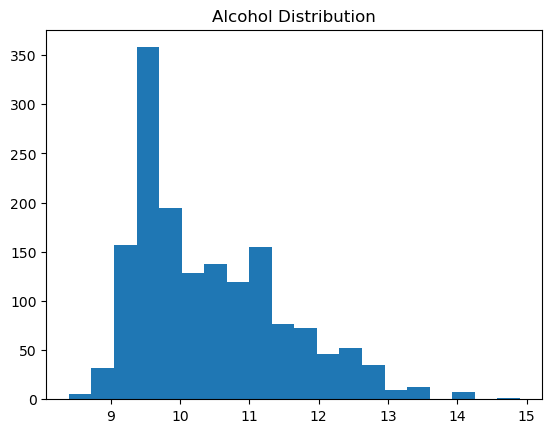

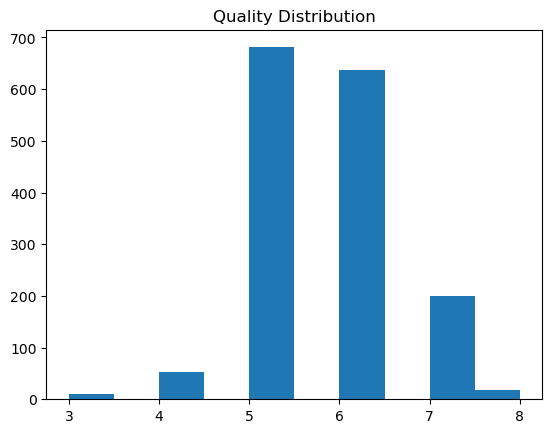

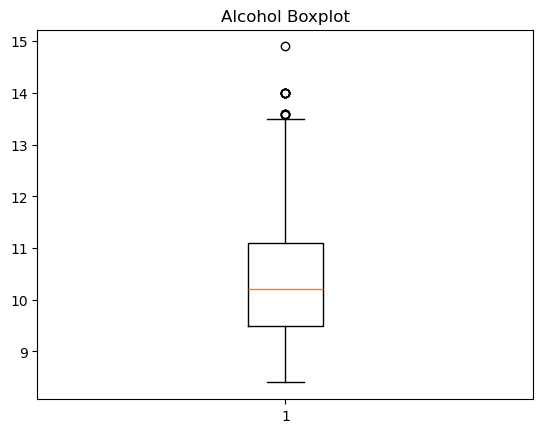

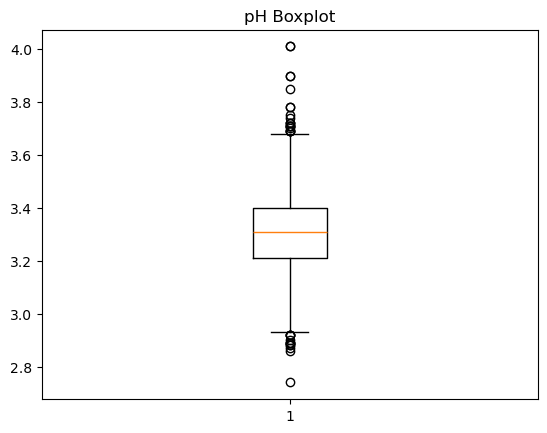

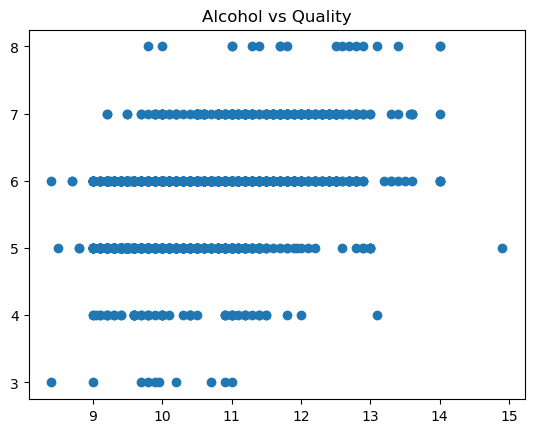

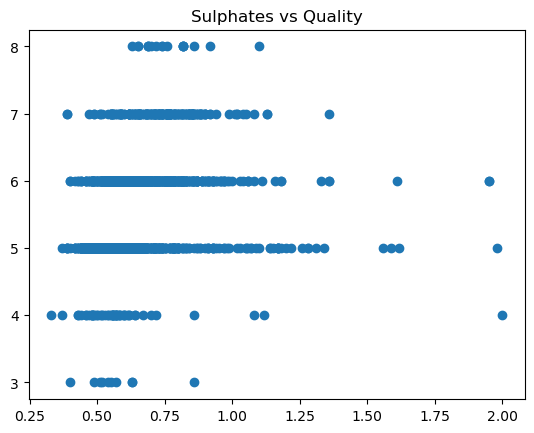

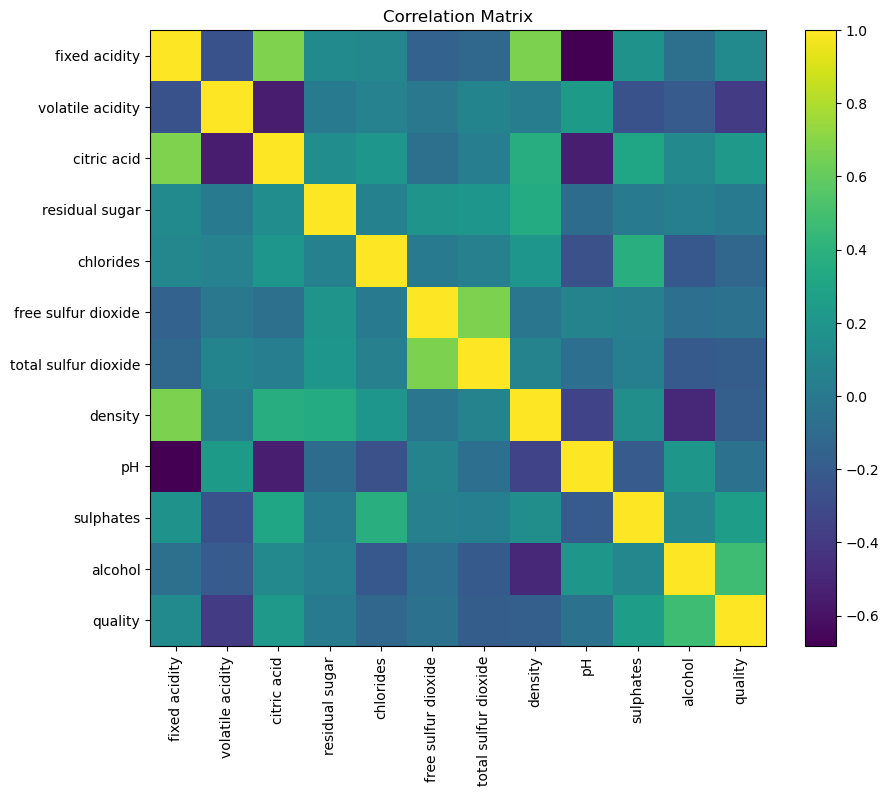

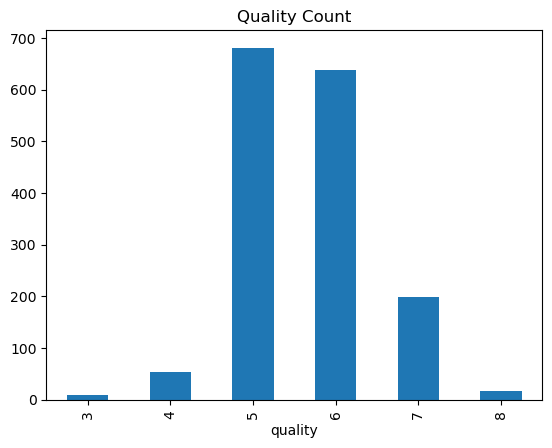

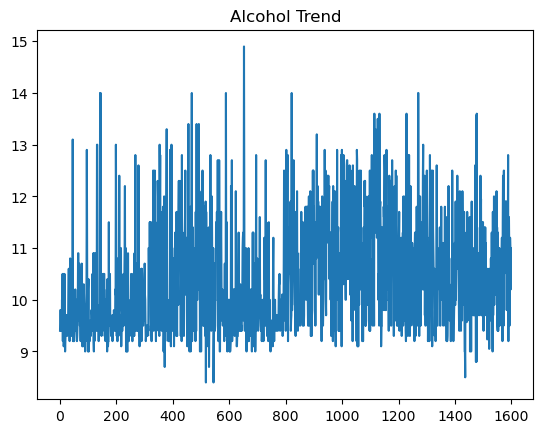

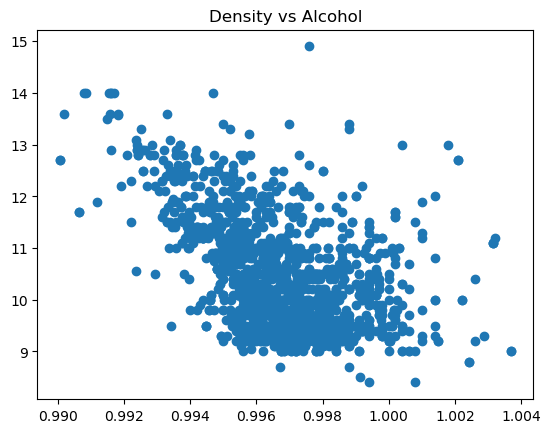


 Model Performance
R2 Score: 0.403180341279623
MSE: 0.39002514396395427
MAE: 0.5035304415524372


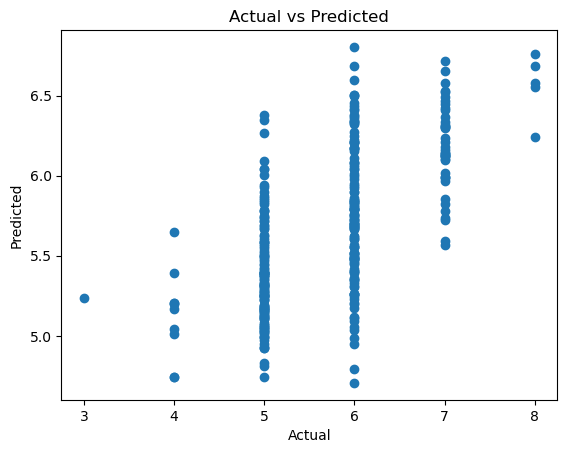


 Pipeline Completed Successfully!


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


FILE_PATH = 'winequality-red.csv'
TARGET = 'quality'
TEST_SIZE = 0.2
RANDOM_STATE = 42


def load_data(path):
    try:
        df = pd.read_csv(path, sep=';')  
    except:
        df = pd.read_csv(path)

    if df.shape[1] == 1:
        print("Fixing single-column issue...")
        df = df[df.columns[0]].str.split(';', expand=True)

        df.columns = [
            'fixed acidity', 'volatile acidity', 'citric acid',
            'residual sugar', 'chlorides', 'free sulfur dioxide',
            'total sulfur dioxide', 'density', 'pH',
            'sulphates', 'alcohol', 'quality'
        ]
        df = df.apply(pd.to_numeric)

    return df

def data_overview(df):
    print("\nShape:", df.shape)
    print("\nColumns:", df.columns.tolist())
    print("\nMissing Values:\n", df.isnull().sum())
    print("\nSummary:\n", df.describe())

# basic EDA
def perform_eda(df):

    # Histogram - Alcohol
    plt.figure()
    plt.hist(df['alcohol'], bins=20)
    plt.title("Alcohol Distribution")
    plt.show()

    # Histogram - Quality
    plt.figure()
    plt.hist(df['quality'], bins=10)
    plt.title("Quality Distribution")
    plt.show()

    # Boxplot - Alcohol
    plt.figure()
    plt.boxplot(df['alcohol'])
    plt.title("Alcohol Boxplot")
    plt.show()

    # Boxplot - pH
    plt.figure()
    plt.boxplot(df['pH'])
    plt.title("pH Boxplot")
    plt.show()

    # Scatter - Alcohol vs Quality
    plt.figure()
    plt.scatter(df['alcohol'], df['quality'])
    plt.title("Alcohol vs Quality")
    plt.show()

    # Scatter - Sulphates vs Quality
    plt.figure()
    plt.scatter(df['sulphates'], df['quality'])
    plt.title("Sulphates vs Quality")
    plt.show()

    # Correlation Heatmap (matplotlib)
    corr = df.corr()
    plt.figure(figsize=(10,8))
    plt.imshow(corr)
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Correlation Matrix")
    plt.show()

    # Bar - Quality Count
    plt.figure()
    df['quality'].value_counts().sort_index().plot(kind='bar')
    plt.title("Quality Count")
    plt.show()

    # Line - Alcohol Trend
    plt.figure()
    plt.plot(df['alcohol'])
    plt.title("Alcohol Trend")
    plt.show()

    # Scatter - Density vs Alcohol
    plt.figure()
    plt.scatter(df['density'], df['alcohol'])
    plt.title("Density vs Alcohol")
    plt.show()

# model training
def train_model(df):

    X = df.drop(TARGET, axis=1)
    y = df[TARGET]

    x_train, x_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    model = LinearRegression()
    model.fit(x_train, y_train)

    return model, x_test, y_test

# model evaluation
def evaluate_model(model, x_test, y_test):

    y_pred = model.predict(x_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    print("\n Model Performance")
    print("R2 Score:", r2)
    print("MSE:", mse)
    print("MAE:", mae)

    # Actual vs Predicted
    plt.figure()
    plt.scatter(y_test, y_pred)
    plt.title("Actual vs Predicted")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.show()

# main pipeline
def main():

    print("Starting ML Pipeline")

    # Load
    df = load_data(FILE_PATH)

    # Overview
    data_overview(df)

    # EDA
    perform_eda(df)

    # Train
    model, x_test, y_test = train_model(df)

    # Evaluate
    evaluate_model(model, x_test, y_test)

    print("\n Pipeline Completed Successfully!")


if __name__ == "__main__":
    main()